In [ ]:
# Rastreamento e Perfil Clínico

#Neste eixo da análise exploratória, avaliamos o impacto direto do rastreamento preventivo de saúde.

#A pergunta de negócio é: **"Pacientes que fizeram exame recente de colesterol (`CholCheck`) têm maior taxa de detecção de colesterol alto (`HighChol`)?"** O objetivo é entender se a ausência de exames subdiagnostica condições clínicas que agravam o risco cardiovascular.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup e Carga
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
cor_primaria = '#0E766D'

In [ ]:
## 1. Tabela de Contingência e Taxa de Detecção
#Isolamos a população em dois grupos: os que realizaram exame de colesterol nos últimos 5 anos e os que não o fizeram, cruzando com a variável de desfecho de colesterol alto.

,Colesterol Normal (0),Colesterol Alto (1),Total
Sem Check-up (0),7489,1981,9470
Com Check-up (1),138600,105610,244210
Total,146089,107591,253680


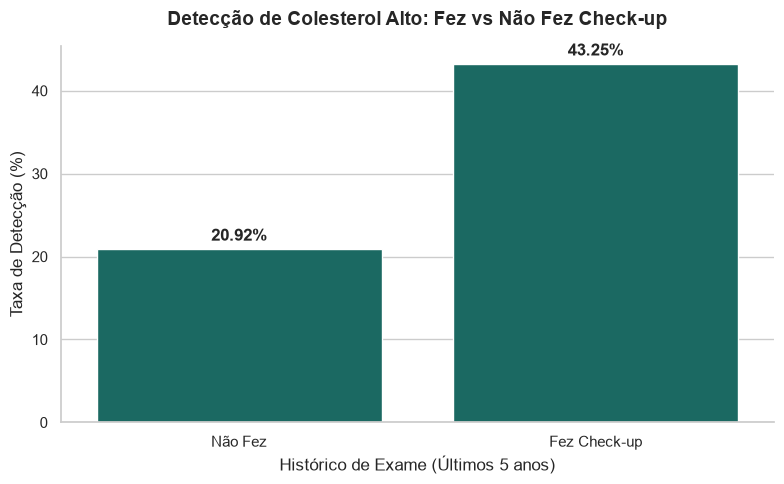

In [11]:
# Tabela 2x2: CholCheck × HighChol
tabela_2x2_chol = pd.crosstab(
    df['CholCheck'],
    df['HighChol'],
    margins=True,
    margins_name="Total"
)
tabela_2x2_chol.columns = ['Colesterol Normal (0)', 'Colesterol Alto (1)', 'Total']
tabela_2x2_chol.index = ['Sem Check-up (0)', 'Com Check-up (1)', 'Total']

display(tabela_2x2_chol)

# Prevalência de Colesterol Alto por Check-up
df_chol_check = df.groupby('CholCheck', observed=False)['HighChol'].agg(
    n='size',
    pct_colesterol_alto='mean'
).reset_index()

df_chol_check['pct_colesterol_alto'] = (df_chol_check['pct_colesterol_alto'] * 100).round(2)
df_chol_check['CholCheck_Label'] = df_chol_check['CholCheck'].map({0: 'Não Fez', 1: 'Fez Check-up'})

# Gráfico de Barras
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df_chol_check, x='CholCheck_Label', y='pct_colesterol_alto', color=cor_primaria)
plt.title('Detecção de Colesterol Alto: Fez vs Não Fez Check-up', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Taxa de Detecção (%)')
plt.xlabel('Histórico de Exame (Últimos 5 anos)')
sns.despine()

for index, row in df_chol_check.iterrows():
    plt.text(index, row['pct_colesterol_alto'] + 1, f"{row['pct_colesterol_alto']}%", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#> **Interpretação:** A análise demonstra um abismo estatístico na detecção. Indivíduos que não realizaram check-up recente apresentam uma taxa de "diagnóstico" artificialmente baixa (~20.9%), indicando que a doença permanece subdiagnosticada e silenciosa na população que não rastreia. Já no grupo com rastreamento ativo (`CholCheck` = 1), a detecção dobra (~43.2%). Isso comprova que a ausência de sintomas não significa ausência de risco, embasando a funcionalidade do aplicativo de sugerir busca clínica.